
--- 1H MODEL (returns target, all features) ---
Using 71 features
Fold 1/5: train 0→1298, test 1298→2596
Fold 2/5: train 0→2596, test 2596→3894
Fold 3/5: train 0→3894, test 3894→5192
Fold 4/5: train 0→5192, test 5192→6490
Fold 5/5: train 0→6490, test 6490→7788
[1h] MAE: 0.6366, RMSE: 0.8807
  Price accuracy: 99.73%   Direction accuracy: 50.03%
Next-bar direction accuracy: 48.10% over 6489 bars


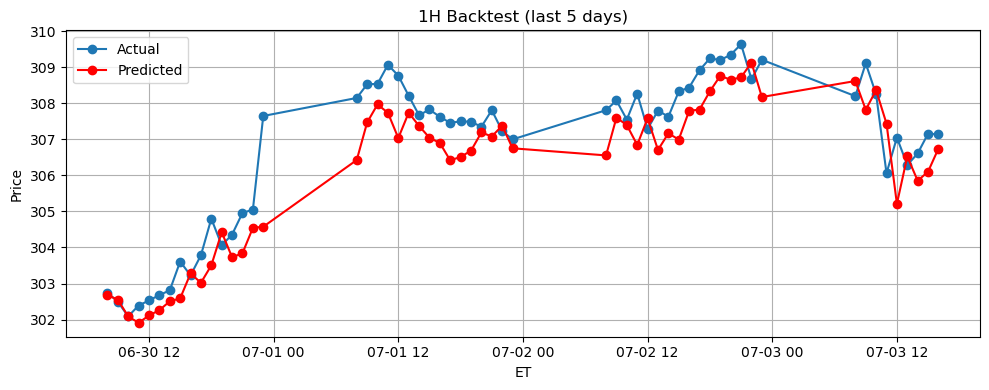

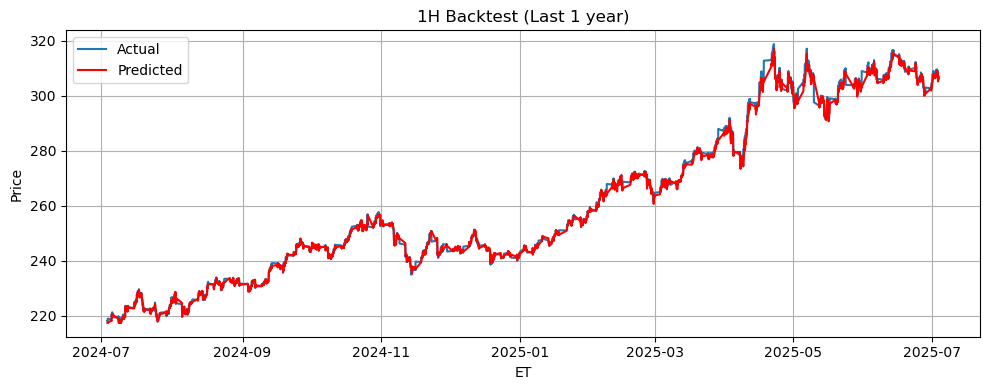

Equity backtest window: 2020-07-03 → 2025-07-03
Equity final (5-year): $107.85 (7.85% return)
Total trades (5-year): 370
Max drawdown (5-year): 6.79%
Win rate (5-year): 59.73%


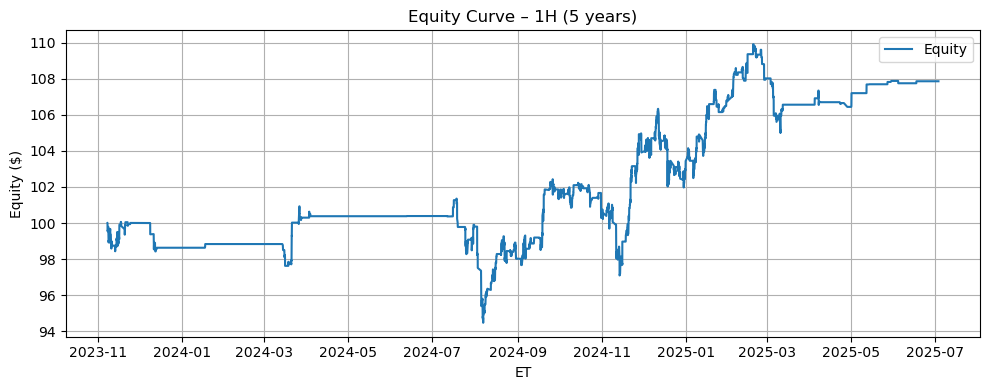

Retraining on full history for next-bar forecast…
Next-bar (1h) at 2025-07-03 17:00 ET → $306.39, dir=1


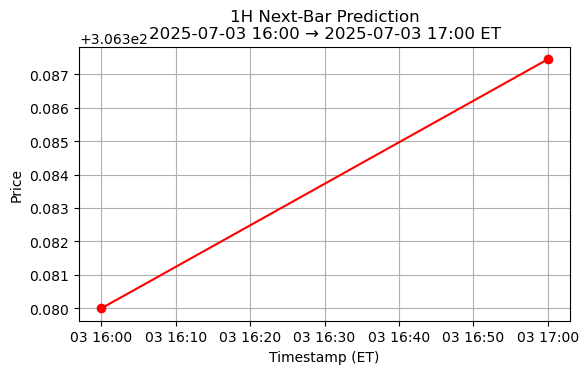


--- 4H MODEL (returns target, all features) ---
Using 71 features
Fold 1/5: train 0→358, test 358→716
Fold 2/5: train 0→716, test 716→1074
Fold 3/5: train 0→1074, test 1074→1432
Fold 4/5: train 0→1432, test 1432→1790
Fold 5/5: train 0→1790, test 1790→2153
[4h] MAE: 1.1872, RMSE: 1.5732
  Price accuracy: 99.50%   Direction accuracy: 46.57%
Next-bar direction accuracy: 50.17% over 1794 bars


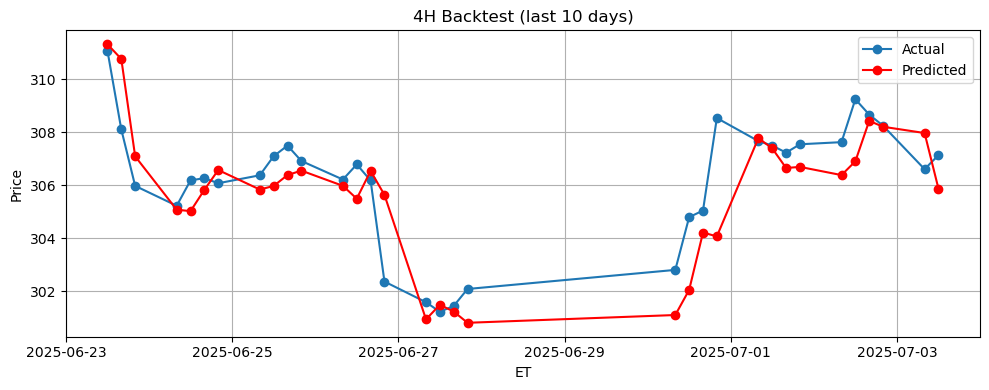

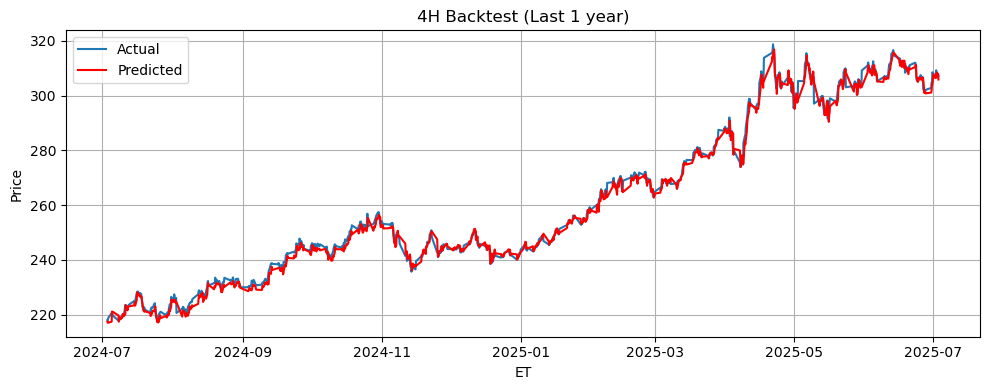

Equity backtest window: 2020-07-03 → 2025-07-03
Equity final (5-year): $115.37 (15.37% return)
Total trades (5-year): 91
Max drawdown (5-year): 5.72%
Win rate (5-year): 62.64%


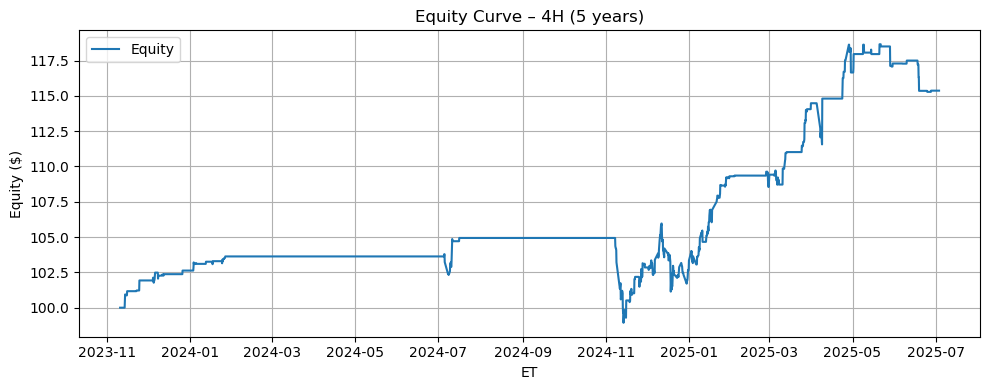

Retraining on full history for next-bar forecast…
Next-bar (4h) at 2025-07-03 20:00 ET → $305.96, dir=0


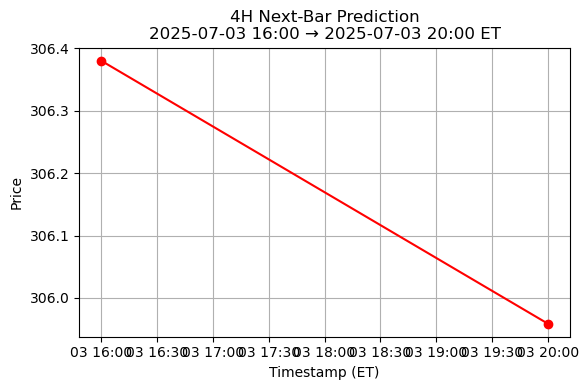


--- 1D MODEL (returns target, all features) ---
Using 71 features
Fold 1/5: train 0→83, test 83→166
Fold 2/5: train 0→166, test 166→249
Fold 3/5: train 0→249, test 249→332
Fold 4/5: train 0→332, test 332→415
Fold 5/5: train 0→415, test 415→498
[1d] MAE: 2.5373, RMSE: 3.3043
  Price accuracy: 98.95%   Direction accuracy: 48.67%
Next-bar direction accuracy: 43.48% over 414 bars


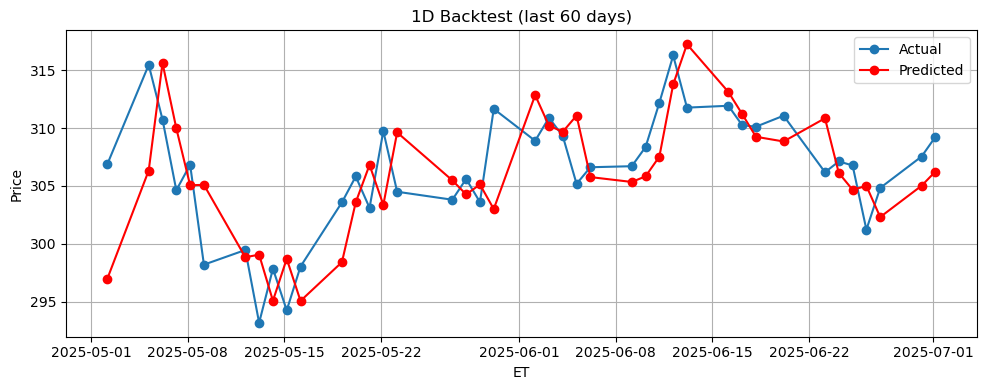

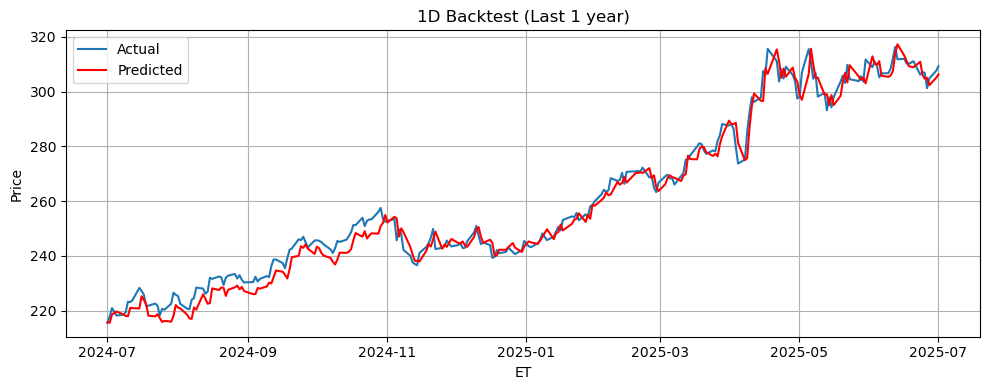

Equity backtest window: 2020-07-01 → 2025-07-01
Equity final (5-year): $130.68 (30.68% return)
Total trades (5-year): 42
Max drawdown (5-year): 7.92%
Win rate (5-year): 69.05%


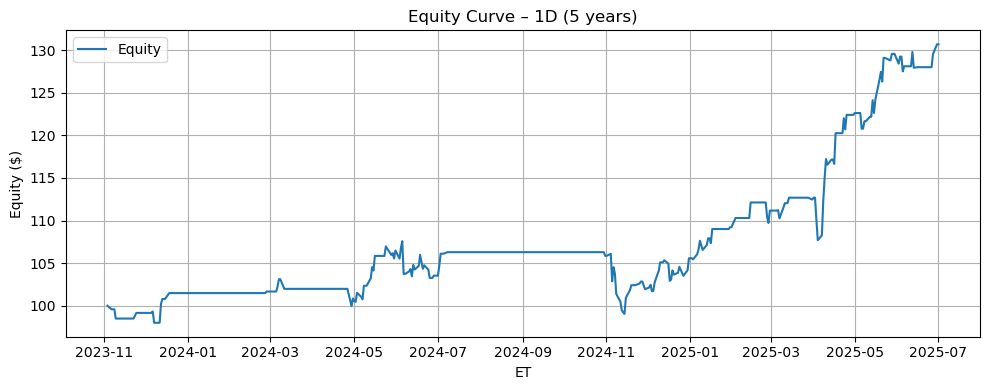

Retraining on full history for next-bar forecast…
Next-bar (1d) at 2025-07-04 00:00 ET → $307.67, dir=1


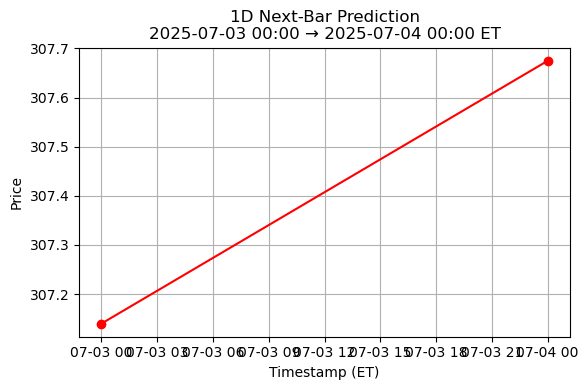


--- 1W MODEL (returns target, all features) ---
Using 71 features
Fold 1/5: train 0→17, test 17→34
Fold 2/5: train 0→34, test 34→51
Fold 3/5: train 0→51, test 51→68
Fold 4/5: train 0→68, test 68→85
Fold 5/5: train 0→85, test 85→105
[1w] MAE: 4.6926, RMSE: 6.0514
  Price accuracy: 98.05%   Direction accuracy: 45.45%
Next-bar direction accuracy: 51.72% over 87 bars


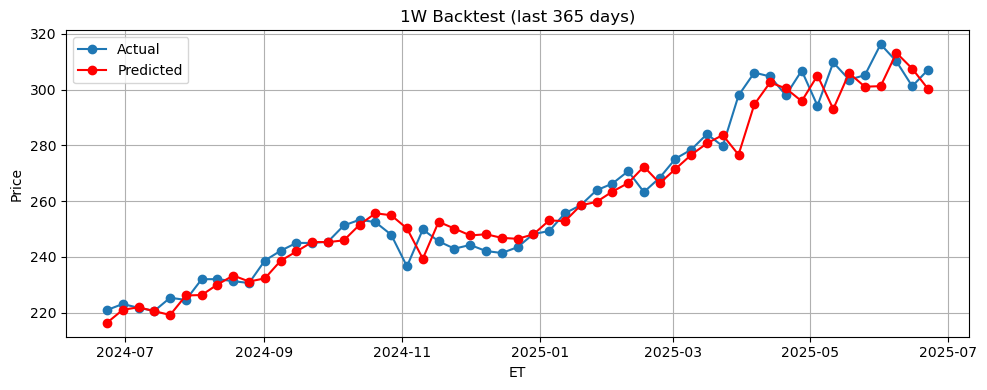

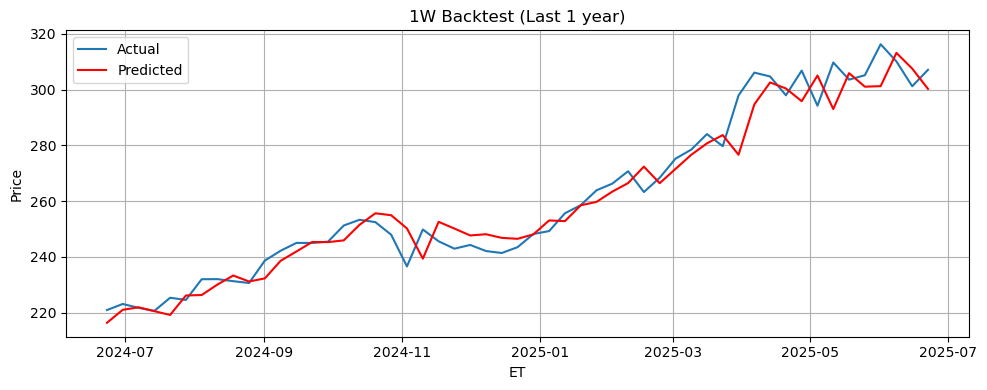

Equity backtest window: 2020-06-22 → 2025-06-22
Equity final (5-year): $124.03 (24.03% return)
Total trades (5-year): 7
Max drawdown (5-year): 6.60%
Win rate (5-year): 71.43%


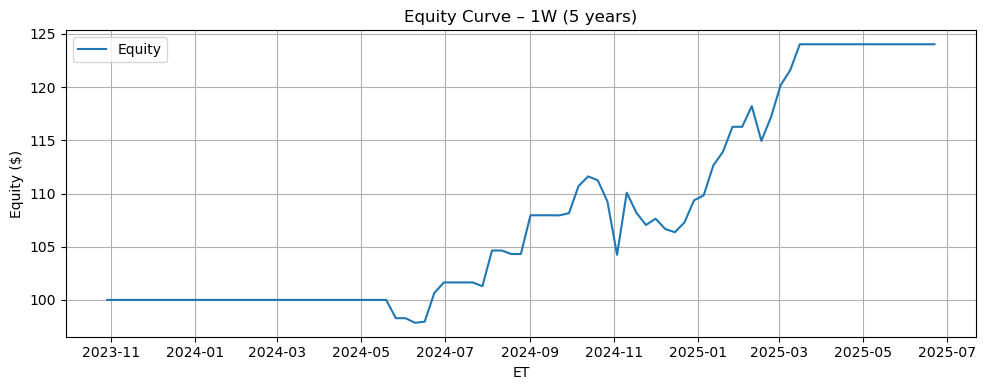

Retraining on full history for next-bar forecast…
Next-bar (1w) at 2025-07-13 00:00 ET → $308.78, dir=1


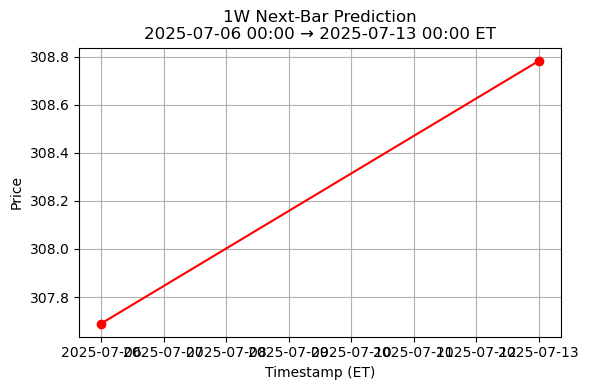

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBRegressor, XGBClassifier
from sklearn.metrics import mean_absolute_error, accuracy_score, mean_squared_error
import pytz

# --- Trading simulation function without stop-loss ---
def simulate_trading(df_eval, initial_capital=100.0, profit_target=1.00, stop_loss=1.00):
    capital = initial_capital
    shares = 0.0
    equity_curve = []
    n_trades = 0
    win_trades = 0
    closed_trades = 0
    peak_equity = initial_capital
    max_drawdown = 0.0
    entry_price = None

    for i in range(len(df_eval) - 1):
        price = df_eval.iloc[i]['actual']
        next_pred = df_eval.iloc[i+1]['predicted']

        if next_pred > price and shares == 0:
            shares = capital / price
            entry_price = price
            n_trades += 1
        # if we already hold shares, first check profit/stop thresholds
        elif shares > 0:
            ret_since_entry = (price / entry_price) - 1.0
            # take-profit
            if ret_since_entry >= profit_target:
                capital = shares * price
                shares = 0.0
                closed_trades += 1
                win_trades += 1
                entry_price = None
            # stop-loss
            elif ret_since_entry <= -stop_loss:
                capital = shares * price
                shares = 0.0
                closed_trades += 1
                entry_price = None
            # otherwise, exit on reversal as before
            elif next_pred < price:
                capital = shares * price
                shares = 0.0
                closed_trades += 1
                if price > entry_price:
                    win_trades += 1
                entry_price = None
        
        equity = shares * price if shares > 0 else capital
        equity_curve.append({'timestamp': df_eval.iloc[i]['timestamp'], 'equity': equity})

        peak_equity = max(peak_equity, equity)
        drawdown = (peak_equity - equity) / peak_equity
        max_drawdown = max(max_drawdown, drawdown)

    last_price = df_eval.iloc[-1]['actual']
    final_equity = shares * last_price if shares > 0 else capital
    equity_curve.append({'timestamp': df_eval.iloc[-1]['timestamp'], 'equity': final_equity})

    peak_equity = max(peak_equity, final_equity)
    drawdown = (peak_equity - final_equity) / peak_equity
    max_drawdown = max(max_drawdown, drawdown)

    win_rate = (win_trades / closed_trades) if closed_trades > 0 else 0.0
    return pd.DataFrame(equity_curve), n_trades, max_drawdown, win_rate

# --- Main function with walk-forward testing ---
def run_model(file_path, freq_label, plot_days, n_splits=5):
    print(f"\n--- {freq_label.upper()} MODEL (returns target, all features) ---")
    eastern = pytz.timezone('America/New_York')

    df = pd.read_csv(file_path, parse_dates=['timestamp'])
    df['timestamp'] = df['timestamp'].dt.tz_localize(eastern)
    df.sort_values('timestamp', inplace=True)

    df['target_price']  = df[f'close_{freq_label}'].shift(-1)
    df['target_return'] = df['target_price'] / df[f'close_{freq_label}'] - 1
    df['target_bin']    = (df['target_return'] > 0).astype(int)
    df.dropna(subset=['target_price','target_return','target_bin'], inplace=True)

    exclude = {'timestamp','target_price','target_return','target_bin'}
    features = [c for c in df.columns if c not in exclude]
    print(f"Using {len(features)} features")

    total_len = len(df)
    split_size = total_len // (n_splits + 1)
    all_preds_price, all_trues_price = [], []
    all_preds_bin, all_trues_bin = [], []
    all_times = []

    xgb_params_reg = dict(
        n_estimators=200, max_depth=5, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, gamma=0.0,
        min_child_weight=1, reg_alpha=0.0, reg_lambda=1.0,
        tree_method='hist', random_state=42,
        objective='reg:squarederror', verbosity=0
    )
    xgb_params_clf = dict(
        n_estimators=200, max_depth=5, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, gamma=0.0,
        min_child_weight=1, reg_alpha=0.0, reg_lambda=1.0,
        scale_pos_weight=1.0, tree_method='hist', random_state=42,
        objective='binary:logistic', eval_metric='logloss', verbosity=0
    )

    for fold in range(n_splits):
        train_end = split_size * (fold + 1)
        test_start = train_end
        test_end = split_size * (fold + 2) if fold < n_splits - 1 else total_len
        print(f"Fold {fold+1}/{n_splits}: train 0→{train_end}, test {test_start}→{test_end}")

        train_idx = list(range(train_end))
        test_idx = list(range(test_start, test_end))

        X_train = df.iloc[train_idx][features].values
        y_train_ret = df.iloc[train_idx]['target_return'].values
        y_train_bin = df.iloc[train_idx]['target_bin'].values

        X_test = df.iloc[test_idx][features].values
        closes_test = df.iloc[test_idx][f'close_{freq_label}'].values
        y_test_price = df.iloc[test_idx]['target_price'].values
        y_test_bin = df.iloc[test_idx]['target_bin'].values

        reg = XGBRegressor(**xgb_params_reg)
        reg.fit(X_train, y_train_ret)
        preds_price = closes_test * (1 + reg.predict(X_test))

        clf = XGBClassifier(**xgb_params_clf)
        clf.fit(X_train, y_train_bin)
        preds_bin = clf.predict(X_test)

        all_preds_price.extend(preds_price)
        all_trues_price.extend(y_test_price)
        all_preds_bin.extend(preds_bin)
        all_trues_bin.extend(y_test_bin)
        all_times.extend(df.iloc[test_idx]['timestamp'].values)

    mae = mean_absolute_error(all_trues_price, all_preds_price)
    rmse = np.sqrt(mean_squared_error(all_trues_price, all_preds_price))
    reg_acc = 100 - np.mean(np.abs((np.array(all_trues_price) - all_preds_price) / (np.array(all_trues_price) + 1e-8))) * 100
    bin_acc = accuracy_score(all_trues_bin, all_preds_bin) * 100
    print(f"[{freq_label}] MAE: {mae:.4f}, RMSE: {rmse:.4f}")
    print(f"  Price accuracy: {reg_acc:.2f}%   Direction accuracy: {bin_acc:.2f}%")

    df_eval = pd.DataFrame({
        'timestamp': all_times,
        'actual': all_trues_price,
        'predicted': all_preds_price
    }).sort_values('timestamp').reset_index(drop=True)
    df_eval['act_dir'] = (df_eval['actual'].shift(-1) > df_eval['actual']).astype(int)
    df_eval['pred_dir'] = (df_eval['predicted'].shift(-1) > df_eval['predicted']).astype(int)
    df_eval = df_eval.iloc[:-1]
    dir_acc = (df_eval['act_dir'] == df_eval['pred_dir']).mean() * 100
    print(f"Next-bar direction accuracy: {dir_acc:.2f}% over {len(df_eval)} bars")

    # 7. Plot actual vs. predicted (predicted in red)
    tz = df_eval['timestamp'].dt.tz
    if tz is None:
        ts = df_eval['timestamp'].dt.tz_localize(eastern)
    else:
        ts = df_eval['timestamp'].dt.tz_convert(eastern)
    df_eval['plot_time'] = ts.dt.tz_localize(None)
    df_bt = df_eval.set_index('plot_time')

    cutoff_plot = df_bt.index.max() - pd.Timedelta(days=plot_days)
    df_plot = df_bt.loc[df_bt.index >= cutoff_plot]
    plt.figure(figsize=(10,4))
    plt.plot(df_plot['actual'], marker='o', label='Actual')
    plt.plot(df_plot['predicted'], marker='o', color='red', label='Predicted')
    plt.title(f"{freq_label.upper()} Backtest (last {plot_days} days)")
    plt.xlabel('ET'); plt.ylabel('Price'); plt.legend(); plt.grid(); plt.tight_layout()
    plt.show()

    cutoff_1yr = df_bt.index.max() - pd.Timedelta(days=365)
    df_1yr = df_bt.loc[df_bt.index >= cutoff_1yr]
    plt.figure(figsize=(10,4))
    plt.plot(df_1yr['actual'], label='Actual')
    plt.plot(df_1yr['predicted'], label='Predicted', color='red')
    plt.title(f"{freq_label.upper()} Backtest (Last 1 year)")
    plt.xlabel('ET'); plt.ylabel('Price'); plt.legend(); plt.grid(); plt.tight_layout()
    plt.show()

    cutoff_5y = df_bt.index.max() - pd.DateOffset(years=5)
    print(f"Equity backtest window: {cutoff_5y.date()} → {df_bt.index.max().date()}")
    df_bt_5y = df_bt.loc[df_bt.index >= cutoff_5y]
    df_last_5y = df_bt_5y.reset_index()[['timestamp','actual','predicted']]

    df_equity, n_trades, max_dd, win_rate = simulate_trading(df_last_5y, initial_capital=100.0)
    init_cap, final_cap = df_equity['equity'].iloc[0], df_equity['equity'].iloc[-1]
    print(f"Equity final (5-year): ${final_cap:.2f} ({(final_cap/init_cap-1)*100:.2f}% return)")
    print(f"Total trades (5-year): {n_trades}")
    print(f"Max drawdown (5-year): {max_dd*100:.2f}%")
    print(f"Win rate (5-year): {win_rate*100:.2f}%")

    plt.figure(figsize=(10,4))
    plt.plot(df_equity['timestamp'], df_equity['equity'], label='Equity')
    plt.title(f"Equity Curve – {freq_label.upper()} (5 years)")
    plt.xlabel('ET'); plt.ylabel('Equity ($)'); plt.legend(); plt.grid(); plt.tight_layout()
    plt.show()

    print("Retraining on full history for next-bar forecast…")
    df_full_raw = pd.read_csv(file_path, parse_dates=['timestamp'])
    df_full_raw['timestamp'] = df_full_raw['timestamp'].dt.tz_localize(eastern)
    df_full_raw.sort_values('timestamp', inplace=True)

    df_full = df_full_raw.copy()
    df_full['tgt_price'] = df_full[f'close_{freq_label}'].shift(-1)
    df_full['tgt_ret']   = df_full['tgt_price'] / df_full[f'close_{freq_label}'] - 1
    df_full['tgt_bin']   = (df_full['tgt_ret'] > 0).astype(int)
    df_full.dropna(subset=['tgt_ret','tgt_bin'], inplace=True)

    X_all     = df_full[features].values
    y_all_ret = df_full['tgt_ret'].values
    y_all_bin = df_full['tgt_bin'].values
    reg_full = XGBRegressor(**xgb_params_reg).fit(X_all, y_all_ret)
    clf_full = XGBClassifier(**xgb_params_clf).fit(X_all, y_all_bin)

    raw_last   = df_full_raw.iloc[-1]
    last_ts    = raw_last['timestamp']
    last_close = raw_last[f'close_{freq_label}']
    feat       = raw_last[features].values.reshape(1, -1)
    pred_ret   = reg_full.predict(feat)[0]
    pred_price = last_close * (1 + pred_ret)
    pred_dir   = int(pred_ret > 0)

    freq_map = {'1m':{'minutes':1}, '5m':{'minutes':5}, '15m':{'minutes':15},
                '30m':{'minutes':30}, '1h':{'hours':1}, '4h':{'hours':4},
                '1d':{'days':1}, '1w':{'weeks':1}}
    next_ts = last_ts + pd.Timedelta(**freq_map[freq_label])

    pd.DataFrame([{'timestamp': next_ts.tz_localize(None), 'predicted_price': pred_price, 'predicted_direction': pred_dir}])\
        .to_csv(f'predictions_{freq_label}.csv', index=False)

    print(f"Next-bar ({freq_label}) at {next_ts.strftime('%Y-%m-%d %H:%M')} ET → ${pred_price:.2f}, dir={pred_dir}")
    t1 = last_ts.tz_convert(eastern).tz_localize(None)
    t2 = next_ts.tz_convert(eastern).tz_localize(None)
    plt.figure(figsize=(6,4))
    plt.plot([t1, t2], [last_close, pred_price], marker='o', linestyle='-', color='red')
    plt.title(f"{freq_label.upper()} Next-Bar Prediction\n{t1.strftime('%Y-%m-%d %H:%M')} → {t2.strftime('%Y-%m-%d %H:%M')} ET")
    plt.xlabel('Timestamp (ET)'); plt.ylabel('Price'); plt.grid(True); plt.tight_layout(); plt.show()

# ---- Activate runs ----
run_model('data_1h.csv', '1h', 5)
run_model('data_4h.csv', '4h', 10)
run_model('data_1d.csv', '1d', 60)
run_model('data_1w.csv', '1w', 365)



=== TIMEFRAME: 1H ===
Loading data from data_1h.csv...
Loaded 7788 rows, features: 75, close_col: close_1h
  • Rows: 7788, span 2023-07-10 04:00:00 -> 2025-07-03 13:00:00
Starting walk-forward backtest…
  • Fold 1/5
  • Fold 2/5
  • Fold 3/5
  • Fold 4/5
  • Fold 5/5
  -> AGGREGATED TEST MAE (return %): 3.363%
  -> AGGREGATED TEST RMSE (return %): 4.607%
  -> AGGREGATED DirAcc (binary):   52.08%


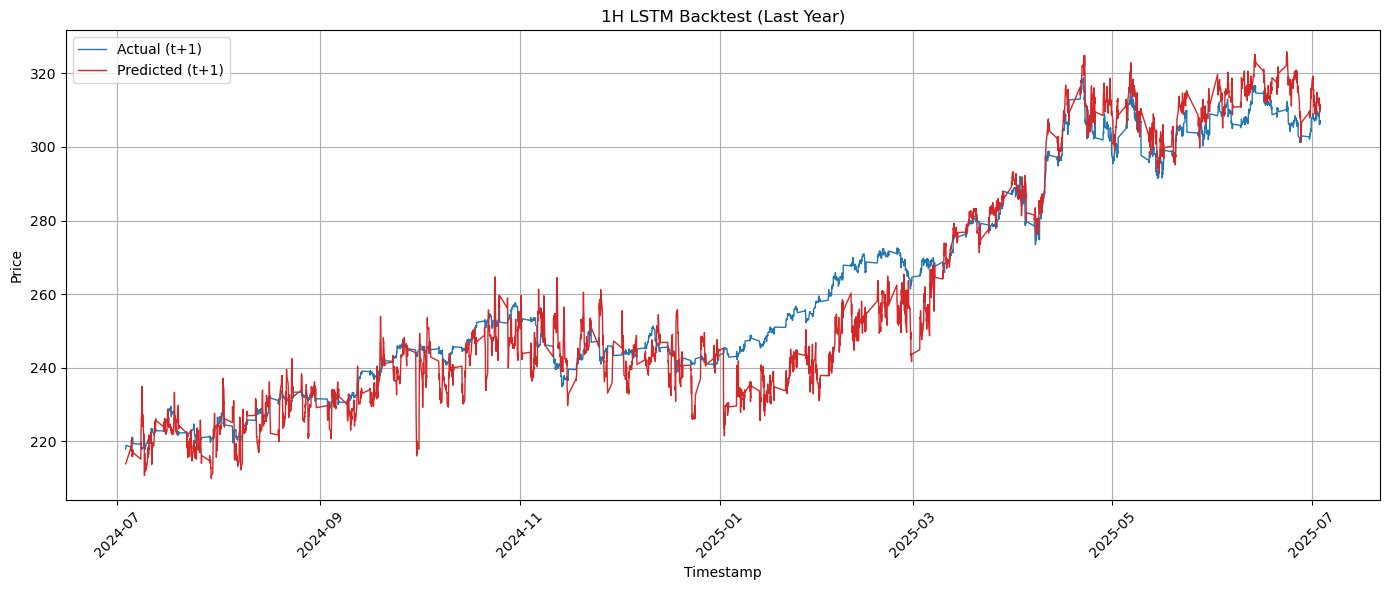

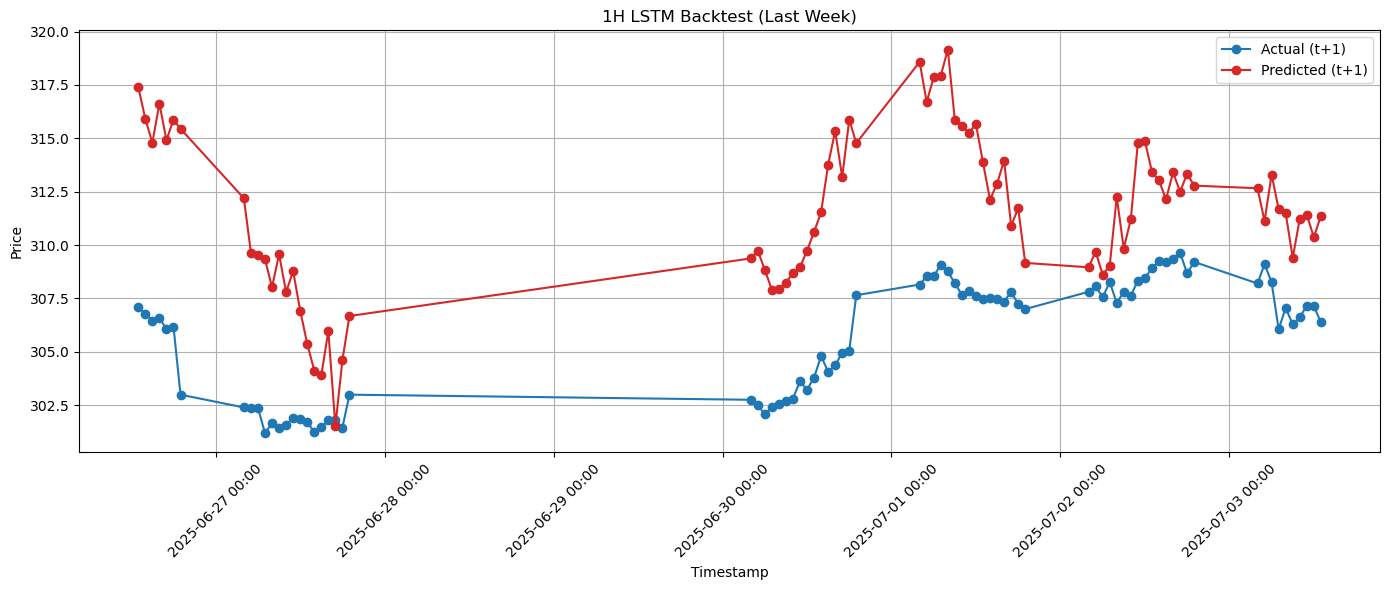

  -> Total Trades Taken: 195
Plotting equity curve for the last 5 years and computing performance metrics…
  -> Final capital (5Y): $122.85
  -> Total % Gain (5Y):   22.85%
  -> Approx. Sharpe (5Y): 0.29
  -> Max Drawdown (5Y):   -9.26%
  -> Win Rate (5Y):       57.95%


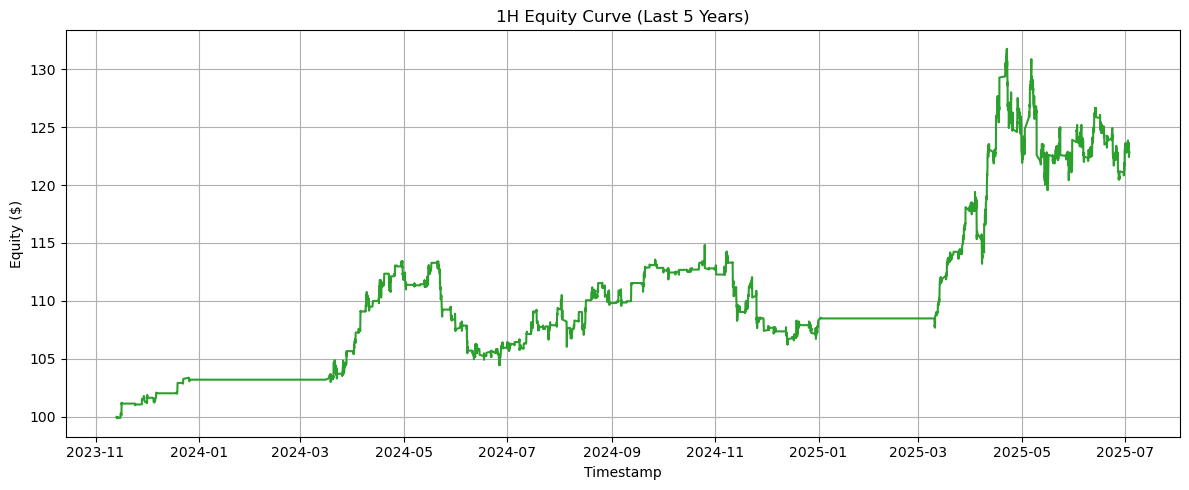

Retraining on full data for latest next-bar prediction…
  • Saved NEXT-BAR forecast -> lstm_outputs/predictions_1h.csv


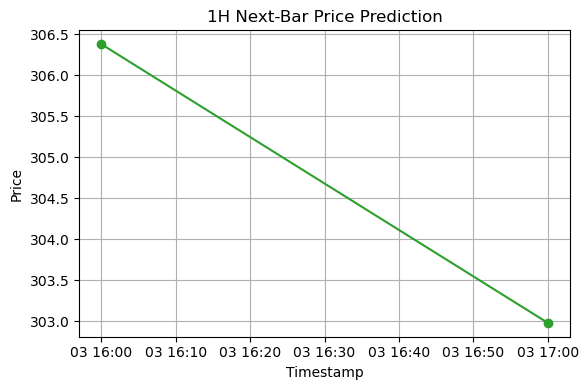


=== TIMEFRAME: 4H ===
Loading data from data_4h.csv...
Loaded 2153 rows, features: 75, close_col: close_4h
  • Rows: 2153, span 2023-07-10 04:00:00 -> 2025-07-03 12:00:00
Starting walk-forward backtest…
  • Fold 1/5
  • Fold 2/5
  • Fold 3/5
  • Fold 4/5
  • Fold 5/5
  -> AGGREGATED TEST MAE (return %): 4.173%
  -> AGGREGATED TEST RMSE (return %): 5.264%
  -> AGGREGATED DirAcc (binary):   53.68%


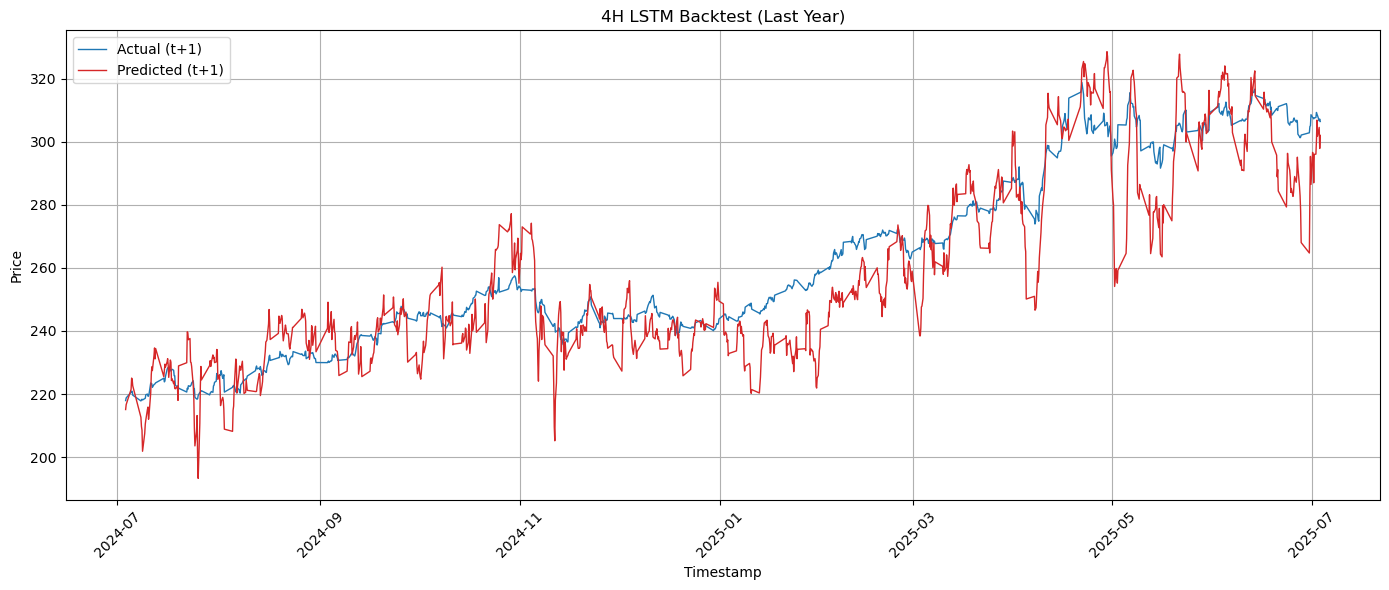

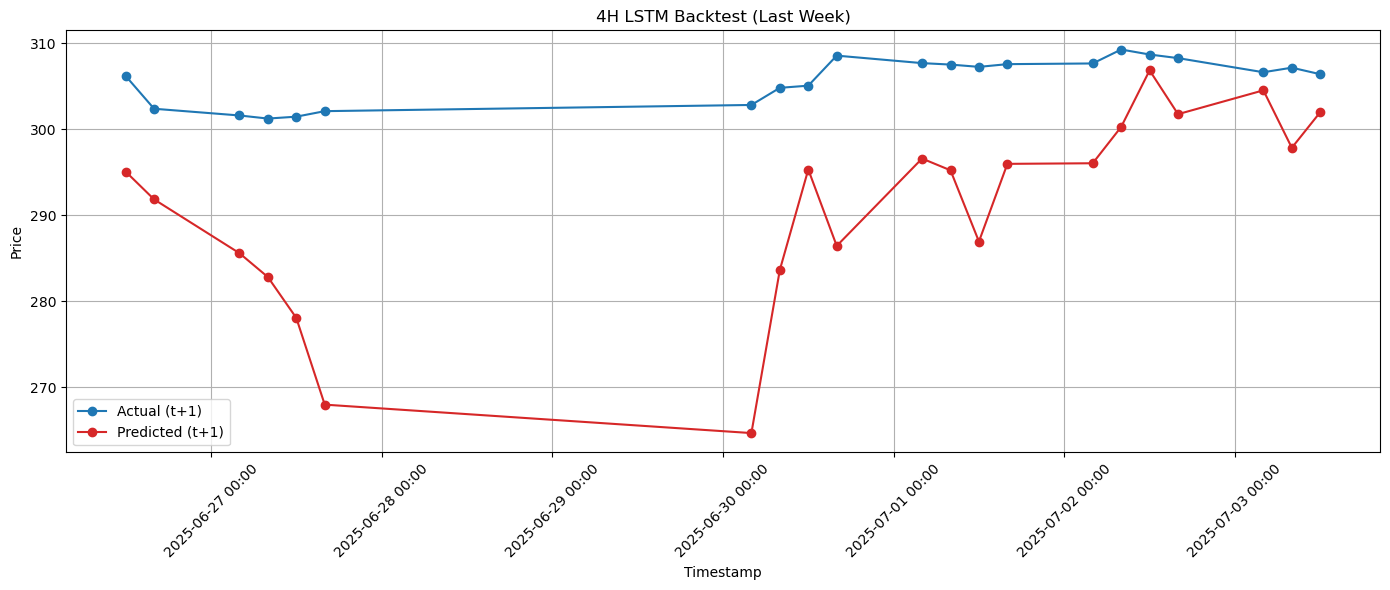

  -> Total Trades Taken: 80
Plotting equity curve for the last 5 years and computing performance metrics…
  -> Final capital (5Y): $130.80
  -> Total % Gain (5Y):   30.80%
  -> Approx. Sharpe (5Y): 0.82
  -> Max Drawdown (5Y):   -8.04%
  -> Win Rate (5Y):       60.00%


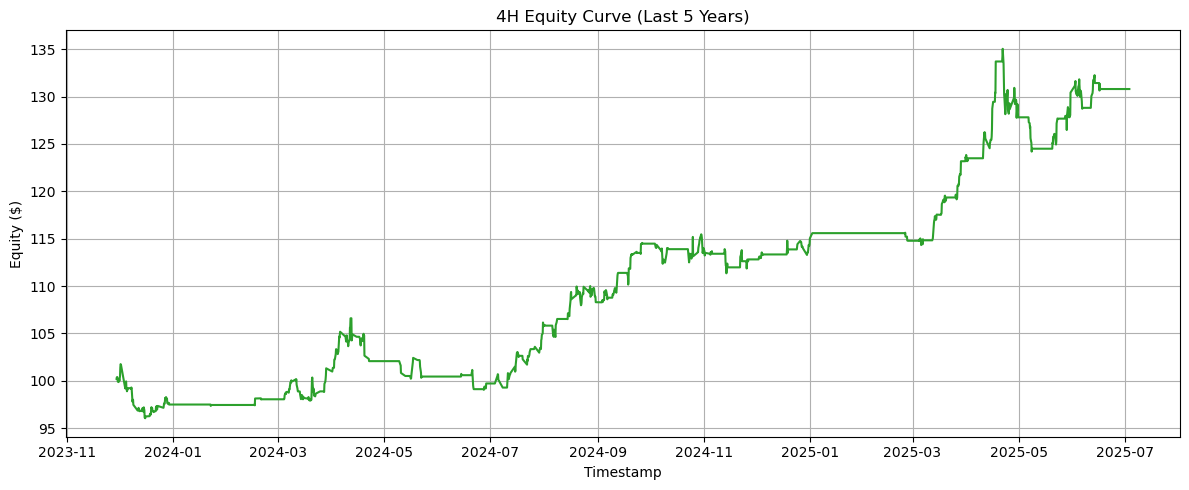

Retraining on full data for latest next-bar prediction…
  • Saved NEXT-BAR forecast -> lstm_outputs/predictions_4h.csv


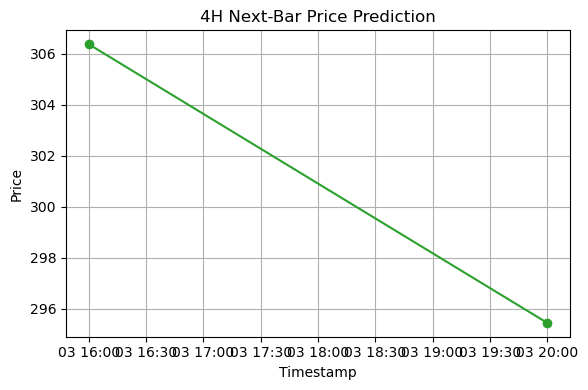


=== TIMEFRAME: 1D ===
Loading data from data_1d.csv...
Loaded 498 rows, features: 75, close_col: close_1d
  • Rows: 498, span 2023-07-10 00:00:00 -> 2025-07-02 00:00:00
Starting walk-forward backtest…
  • Fold 1/5
  • Fold 2/5
  • Fold 3/5
  • Fold 4/5
  • Fold 5/5
  -> AGGREGATED TEST MAE (return %): 10.181%
  -> AGGREGATED TEST RMSE (return %): 13.072%
  -> AGGREGATED DirAcc (binary):   57.53%


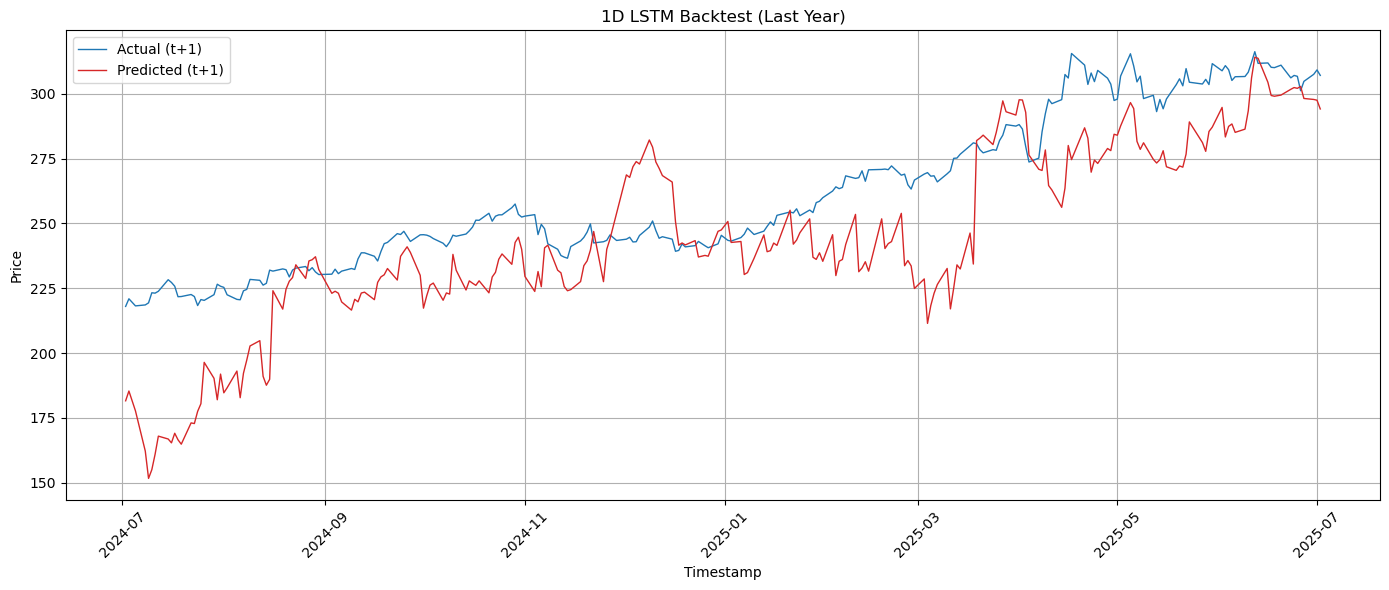

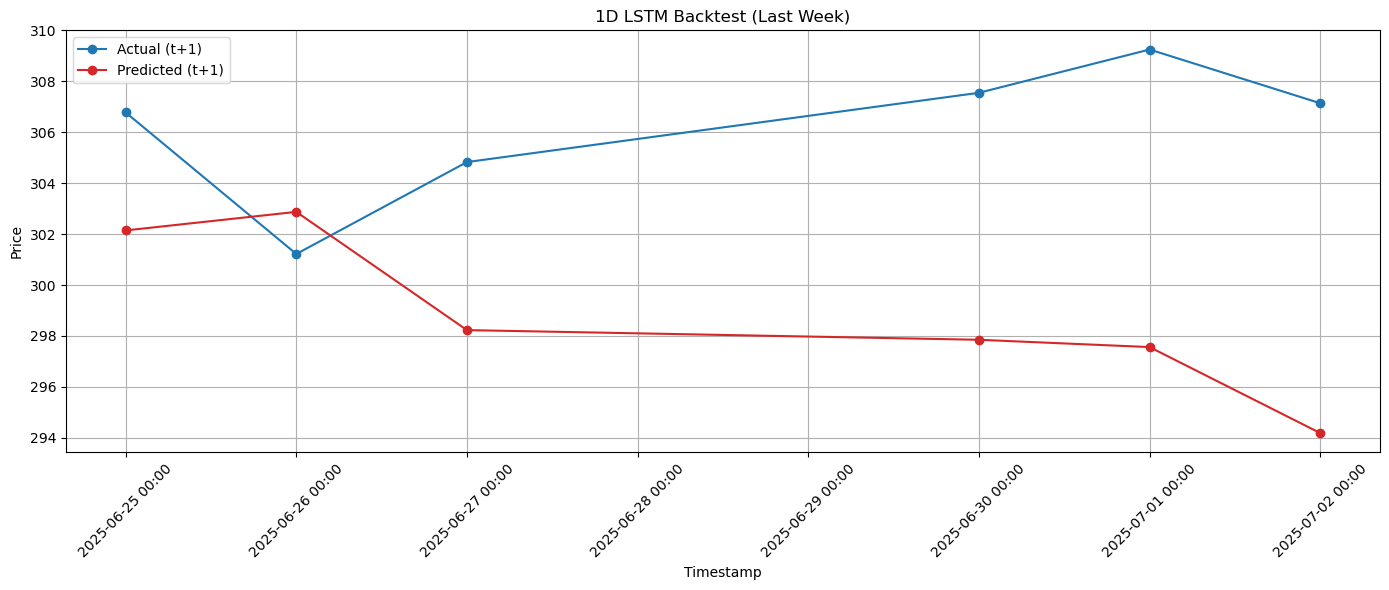

  -> Total Trades Taken: 12
Plotting equity curve for the last 5 years and computing performance metrics…
  -> Final capital (5Y): $104.86
  -> Total % Gain (5Y):   4.86%
  -> Approx. Sharpe (5Y): 0.58
  -> Max Drawdown (5Y):   -5.14%
  -> Win Rate (5Y):       66.67%


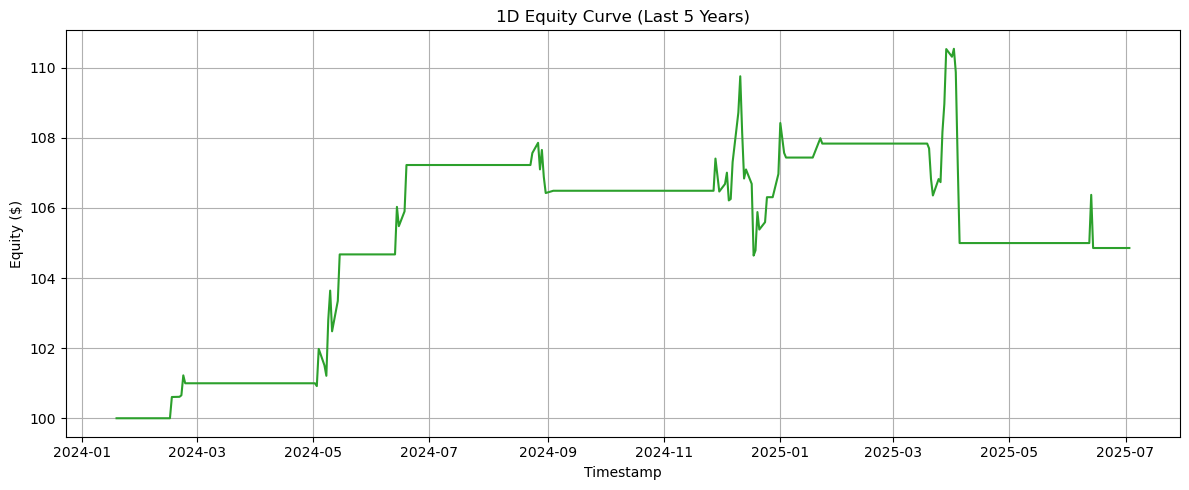

Retraining on full data for latest next-bar prediction…
  • Saved NEXT-BAR forecast -> lstm_outputs/predictions_1d.csv


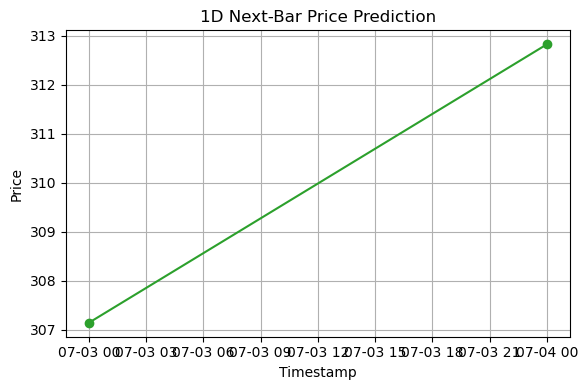


=== TIMEFRAME: 1W ===
Loading data from data_1w.csv...
Loaded 105 rows, features: 75, close_col: close_1w
  • Rows: 105, span 2023-07-02 00:00:00 -> 2025-06-29 00:00:00
Starting walk-forward backtest…
  • Fold 1/5
  • Fold 2/5
  • Fold 3/5
  • Fold 4/5
  • Fold 5/5
  -> AGGREGATED TEST MAE (return %): 7.282%
  -> AGGREGATED TEST RMSE (return %): 9.344%
  -> AGGREGATED DirAcc (binary):   40.00%


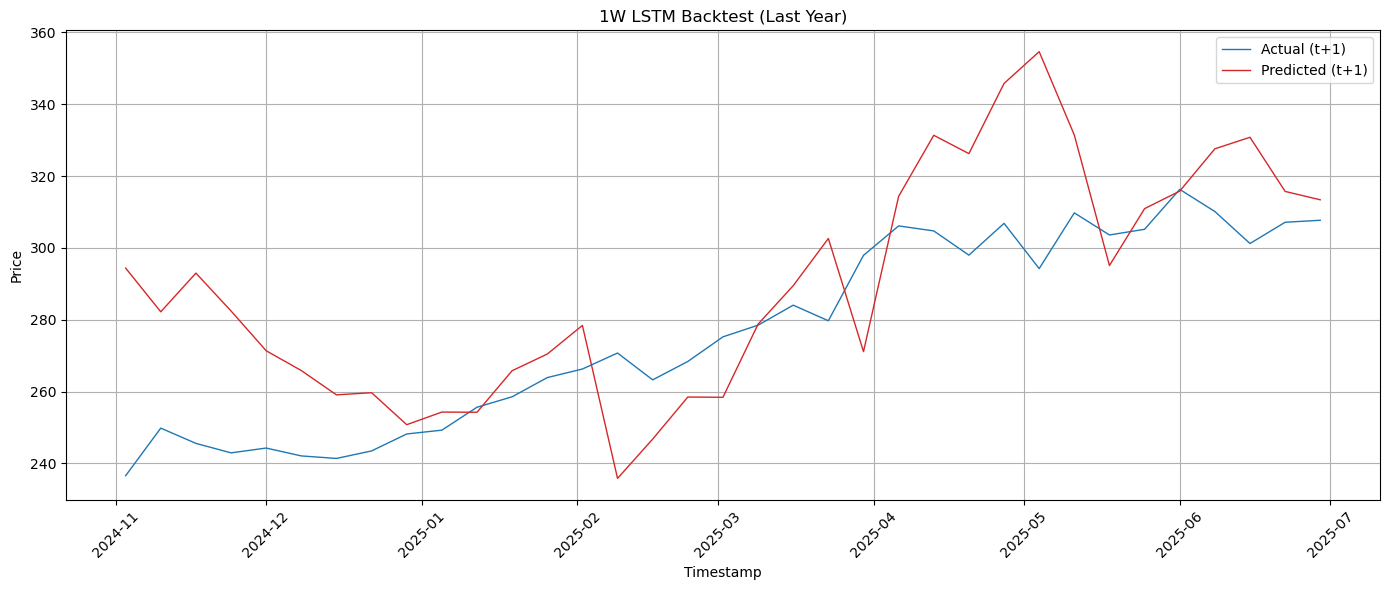

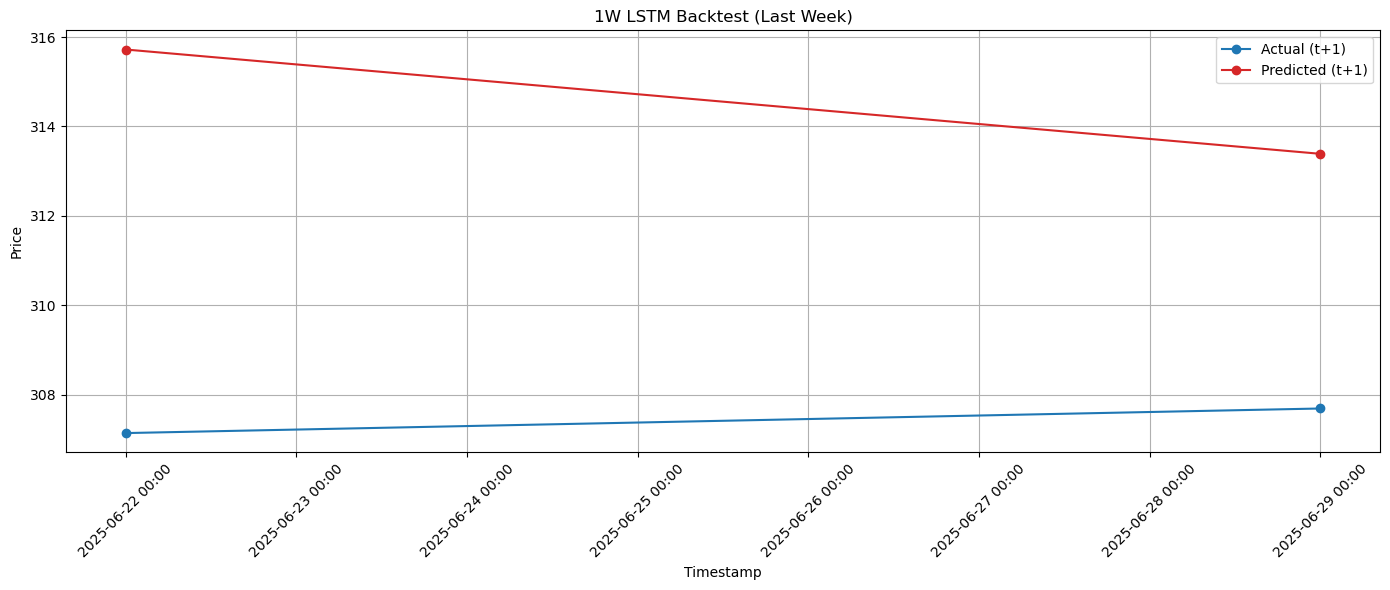

  -> Total Trades Taken: 4
Plotting equity curve for the last 5 years and computing performance metrics…
  -> Final capital (5Y): $121.84
  -> Total % Gain (5Y):   21.84%
  -> Approx. Sharpe (5Y): 4.99
  -> Max Drawdown (5Y):   -4.76%
  -> Win Rate (5Y):       75.00%


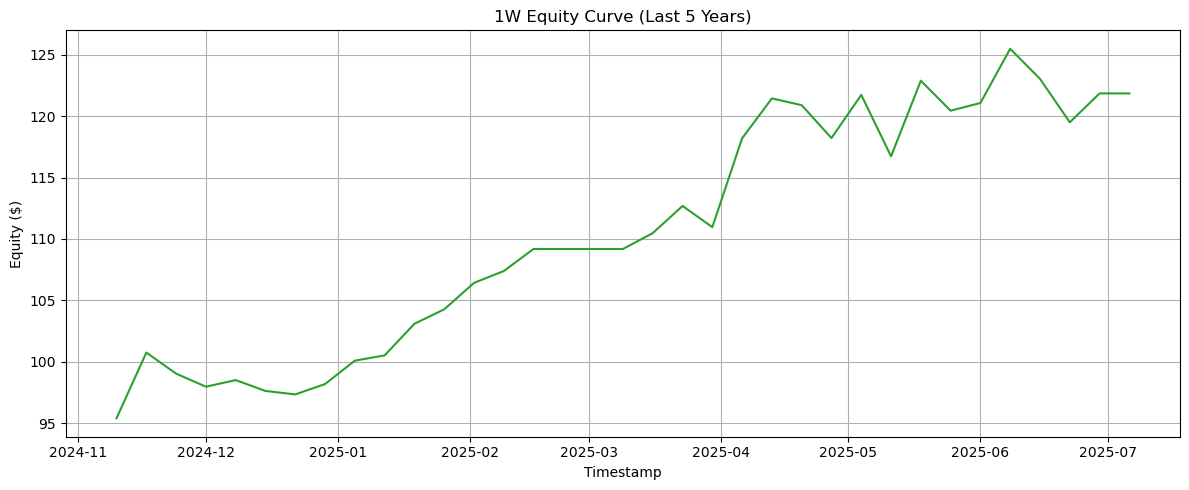

Retraining on full data for latest next-bar prediction…
  • Saved NEXT-BAR forecast -> lstm_outputs/predictions_1w.csv


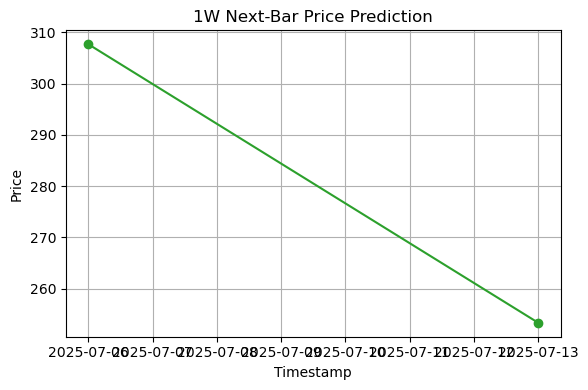


All timeframes completed.


In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.dates import DateFormatter
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, accuracy_score
from sklearn.model_selection import TimeSeriesSplit
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
import os
from datetime import timedelta
import warnings

# === CONFIGURATION ===
active_timeframes = ['1h', '4h', '1d', '1w']
data_files = {
    '1h': 'data_1h.csv',
    '4h': 'data_4h.csv',
    '1d': 'data_1d.csv',
    '1w': 'data_1w.csv'
}
output_dir = 'lstm_outputs'
os.makedirs(output_dir, exist_ok=True)

SEQ_LENGTH = 60
N_SPLITS = 5  # number of walk-forward folds

freq_steps = {
    '1h': timedelta(hours=1),
    '4h': timedelta(hours=4),
    '1d': timedelta(days=1),
    '1w': timedelta(weeks=1),
}

warnings.filterwarnings('ignore', category=UserWarning, module='sklearn')


def load_data(file_path):
    print(f"Loading data from {file_path}...")
    df = pd.read_csv(file_path, parse_dates=['timestamp'], index_col='timestamp')
    df.index = pd.to_datetime(df.index, errors='coerce')
    df = df[~df.index.isna()]
    df.sort_index(inplace=True)

    close_col = next((c for c in df.columns if c.lower().startswith('close_')), None)
    if close_col is None:
        raise ValueError(f"No column starting with 'close_' found in {file_path}")

    # indicators
    df['return_1'] = df[close_col].pct_change()
    df['SMA_10'] = df[close_col].rolling(10, min_periods=10).mean()
    df['SMA_20'] = df[close_col].rolling(20, min_periods=20).mean()
    delta = df[close_col].diff()
    up = delta.clip(lower=0)
    down = (-delta).clip(lower=0)
    roll_up = up.rolling(14, min_periods=14).mean()
    roll_down = down.rolling(14, min_periods=14).mean()
    RS = roll_up / (roll_down + 1e-9)
    df['RSI_14'] = 100.0 - (100.0 / (1.0 + RS))

    # targets
    df['target_reg'] = df[close_col].shift(-1) / df[close_col] - 1.0
    df['target_bin'] = (df['target_reg'] > 0).astype(int)
    df.dropna(subset=['target_reg', 'target_bin'], inplace=True)

    numeric = df.select_dtypes(include=[np.number]).columns.tolist()
    feature_cols = [c for c in numeric if c not in ('target_reg','target_bin')]
    feat = df[feature_cols].ffill().bfill().dropna(axis=1, how='all')

    y_reg = df['target_reg'].loc[feat.index].values
    y_bin = df['target_bin'].loc[feat.index].values

    print(f"Loaded {len(feat)} rows, features: {len(feature_cols)}, close_col: {close_col}")
    return feat, y_reg, y_bin, close_col


def create_sequences(X, y_reg, y_bin, seq_len):
    Xs, yrs, ybs, idxs = [], [], [], []
    for i in range(seq_len, len(X)):
        Xs.append(X[i-seq_len:i])
        yrs.append(y_reg[i])
        ybs.append(y_bin[i])
        idxs.append(i)
    return np.array(Xs), np.array(yrs), np.array(ybs), np.array(idxs)


def build_model(n_features):
    inp = Input(shape=(SEQ_LENGTH, n_features))
    x = LSTM(50)(inp)
    x = Dropout(0.2)(x)
    r = Dense(1, name='reg_output')(x)
    b = Dense(1, activation='sigmoid', name='bin_output')(x)
    model = Model(inputs=inp, outputs=[r, b])
    model.compile(
        optimizer=Adam(learning_rate=3e-4),
        loss={'reg_output': 'mse', 'bin_output': 'binary_crossentropy'},
        loss_weights={'reg_output': 0.5, 'bin_output': 0.5}
    )
    # --- FIX: pre-build the internal tf.function for predict to avoid retracing warnings ---
    model.make_predict_function()
    return model


for tf in active_timeframes:
    print(f"\n=== TIMEFRAME: {tf.upper()} ===")
    fp = data_files.get(tf, "")
    if not os.path.isfile(fp):
        print(f"  • File not found: {fp}. Skipping.")
        continue

    # --- load & prepare ---
    feat_df, y_reg_all, y_bin_all, close_col = load_data(fp)
    if len(feat_df) <= SEQ_LENGTH:
        print("  • Not enough data after cleaning. Skipping.")
        continue

    print(f"  • Rows: {len(feat_df)}, span {feat_df.index.min()} -> {feat_df.index.max()}")

    scaler = MinMaxScaler()
    X_scaled = scaler.fit_transform(feat_df.values.astype('float32'))

    X_all, y_reg_all, y_bin_all, idxs_all = create_sequences(
        X_scaled, y_reg_all, y_bin_all, SEQ_LENGTH
    )
    ts_all = feat_df.index.values[idxs_all]
    close_prices = feat_df[close_col].values

    # --- walk-forward backtest ---
    print("Starting walk-forward backtest…")
    tscv = TimeSeriesSplit(n_splits=N_SPLITS)

    wf_equity   = []
    wf_trades   = 0
    wf_wins     = 0
    wf_capital  = 100.0
    wf_position = 0.0
    # — profit / stop-loss settings —
    profit_target = 1.00    # close when +15% P&L
    stop_loss     = -1.00   # close when −5% P&L
    
    # for aggregated metrics & plots
    all_preds_reg, all_preds_bin = [], []
    all_y_reg, all_y_bin = [], []
    all_idxs, all_ts = [], []

    for fold, (train_ix, test_ix) in enumerate(tscv.split(X_all), 1):
        print(f"  • Fold {fold}/{N_SPLITS}")
        X_tr, X_te = X_all[train_ix], X_all[test_ix]
        yr_tr, yb_tr = y_reg_all[train_ix], y_bin_all[train_ix]
        idx_te = idxs_all[test_ix]
        ts_te = ts_all[test_ix]

        # train
        model = build_model(X_all.shape[2])
        model.fit(
            X_tr,
            {'reg_output': yr_tr, 'bin_output': yb_tr},
            epochs=3, batch_size=32, verbose=0
        )

        # predict (fixed batch_size avoids retracing)
        ypr, ypb = model.predict(X_te, batch_size=32, verbose=0)
        ypr = ypr.flatten()
        ypb = (ypb.flatten() > 0.5).astype(int)

        # collect
        all_preds_reg.append(ypr)
        all_preds_bin.append(ypb)
        all_y_reg.append(y_reg_all[test_ix])
        all_y_bin.append(y_bin_all[test_ix])
        all_idxs.append(idx_te)
        all_ts.append(ts_te)

        # simulate trades
        for i, idx in enumerate(idx_te):
            price  = close_prices[idx]
            next_p = close_prices[idx+1] if idx+1 < len(close_prices) else price
            pred_p = price * (1 + ypr[i])

            # — ENTRY —
            if wf_position == 0 and pred_p > price:
                wf_position = wf_capital / price
                entry_price = price
                wf_capital  = 0.0
                wf_trades  += 1

            # — EXIT —
            elif wf_position > 0:
                # current P&L since entry
                pnl = (price - entry_price) / entry_price

                # 1) profit-target or stop-loss hit?
                if pnl >= profit_target or pnl <= stop_loss:
                    if pnl > 0:
                        wf_wins += 1
                    # exit at current price
                    wf_capital  = wf_position * price
                    wf_position = 0.0

                # 2) otherwise, your original pred-based exit
                elif pred_p < price:
                    if next_p > entry_price:
                        wf_wins += 1
                    wf_capital  = wf_position * next_p
                    wf_position = 0.0

            # record equity
            equity = wf_capital if wf_position == 0 else wf_position * next_p
            wf_equity.append({
                'timestamp': pd.Timestamp(ts_te[i]) + freq_steps[tf],
                'equity': equity
            })


    # flatten arrays
    all_preds_reg = np.concatenate(all_preds_reg)
    all_preds_bin = np.concatenate(all_preds_bin)
    all_y_reg = np.concatenate(all_y_reg)
    all_y_bin = np.concatenate(all_y_bin)
    all_idxs = np.concatenate(all_idxs)
    all_ts = np.concatenate(all_ts)

    # metrics
    mae = mean_absolute_error(all_y_reg, all_preds_reg) * 100
    rmse = np.sqrt(mean_squared_error(all_y_reg, all_preds_reg)) * 100
    dir_acc = accuracy_score(all_y_bin, all_preds_bin) * 100

    print(f"  -> AGGREGATED TEST MAE (return %): {mae:.3f}%")
    print(f"  -> AGGREGATED TEST RMSE (return %): {rmse:.3f}%")
    print(f"  -> AGGREGATED DirAcc (binary):   {dir_acc:.2f}%")

    # 1-YEAR & 1-WEEK price vs predicted
    actual_prices = close_prices[all_idxs] * (1 + all_y_reg)
    predicted_prices = close_prices[all_idxs] * (1 + all_preds_reg)

    cutoff_1y = all_ts.max() - pd.Timedelta(days=365)
    m1 = all_ts >= cutoff_1y
    plt.figure(figsize=(14,6))
    plt.plot(all_ts[m1], actual_prices[m1], label='Actual (t+1)', color='C0', linewidth=1)
    plt.plot(all_ts[m1], predicted_prices[m1], label='Predicted (t+1)', color='C3', linewidth=1)
    plt.title(f"{tf.upper()} LSTM Backtest (Last Year)")
    plt.xlabel("Timestamp"); plt.ylabel("Price")
    plt.legend(); plt.grid(True)
    plt.gca().xaxis.set_major_formatter(DateFormatter("%Y-%m"))
    plt.xticks(rotation=45); plt.tight_layout(); plt.show()

    cutoff_1w = all_ts.max() - pd.Timedelta(days=7)
    m2 = all_ts >= cutoff_1w
    if m2.any():
        plt.figure(figsize=(14,6))
        plt.plot(all_ts[m2], actual_prices[m2], marker='o', linestyle='-', label='Actual (t+1)', color='C0')
        plt.plot(all_ts[m2], predicted_prices[m2], marker='o', linestyle='-', label='Predicted (t+1)', color='C3')
        plt.title(f"{tf.upper()} LSTM Backtest (Last Week)")
        plt.xlabel("Timestamp"); plt.ylabel("Price")
        plt.legend(); plt.grid(True)
        plt.gca().xaxis.set_major_formatter(DateFormatter("%Y-%m-%d %H:%M"))
        plt.xticks(rotation=45); plt.tight_layout(); plt.show()

    # equity curve & perf metrics
    eq_df = pd.DataFrame(wf_equity).set_index('timestamp').sort_index()
    final_cap = eq_df['equity'].iloc[-1]
    pct_gain  = (final_cap - 100.0) / 100.0 * 100
    rets      = eq_df['equity'].pct_change().dropna()
    sharpe    = rets.mean() / (rets.std()+1e-9) * np.sqrt(252) if not rets.empty else 0
    drawdown  = (eq_df['equity']/eq_df['equity'].cummax() - 1).min() * 100
    win_rate  = (wf_wins / wf_trades * 100) if wf_trades > 0 else 0.0
    print(f"  -> Total Trades Taken: {wf_trades}")

    print("Plotting equity curve for the last 5 years and computing performance metrics…")
    print(f"  -> Final capital (5Y): ${final_cap:.2f}")
    print(f"  -> Total % Gain (5Y):   {pct_gain:.2f}%")
    print(f"  -> Approx. Sharpe (5Y): {sharpe:.2f}")
    print(f"  -> Max Drawdown (5Y):   {drawdown:.2f}%")
    print(f"  -> Win Rate (5Y):       {win_rate:.2f}%")

    cutoff_5y = eq_df.index.max() - pd.DateOffset(years=5)
    eq5 = eq_df.loc[eq_df.index >= cutoff_5y] if not eq_df.empty else eq_df
    plt.figure(figsize=(12,5))
    plt.plot(eq5.index, eq5['equity'], label='Equity', color='C2')
    plt.title(f"{tf.upper()} Equity Curve (Last 5 Years)")
    plt.xlabel("Timestamp"); plt.ylabel("Equity ($)")
    plt.grid(True); plt.tight_layout(); plt.show()

    # === FINAL NEXT-BAR PREDICTION ===
    print("Retraining on full data for latest next-bar prediction…")
    model.fit(
        X_all,
        {'reg_output': y_reg_all, 'bin_output': y_bin_all},
        epochs=3, batch_size=32, verbose=0
    )

    raw_df = pd.read_csv(fp, parse_dates=['timestamp'], index_col='timestamp')
    raw_df.index = pd.to_datetime(raw_df.index)
    raw = raw_df.copy()
    raw['return_1'] = raw[close_col].pct_change()
    raw['SMA_10'] = raw[close_col].rolling(10, min_periods=10).mean()
    raw['SMA_20'] = raw[close_col].rolling(20, min_periods=20).mean()
    delta = raw[close_col].diff()
    up = delta.clip(lower=0)
    down = (-delta).clip(lower=0)
    ru = up.rolling(14, min_periods=14).mean()
    rd = down.rolling(14, min_periods=14).mean()
    RS = ru / (rd + 1e-9)
    raw['RSI_14'] = 100 - (100 / (1 + RS))

    rf = raw[feat_df.columns].ffill().bfill()
    full_scaled = scaler.transform(rf.values.astype('float32'))
    last_seq = np.expand_dims(full_scaled[-SEQ_LENGTH:], axis=0)
    pr, pd_bin = model(last_seq, training=False)
    pr = float(pr.numpy().flatten()[0])
    pd_bin = int((pd_bin.numpy().flatten()[0] > 0.5).astype(int))

    last_close = raw_df[close_col].iloc[-1]
    next_ts = raw_df.index[-1] + freq_steps[tf]
    pred_price = last_close * (1 + pr)

    outfile = os.path.join(output_dir, f"predictions_{tf}.csv")
    pd.DataFrame([{ 'timestamp': next_ts,
                    'predicted_price': pred_price,
                    'predicted_direction': pd_bin
    }]).to_csv(outfile, index=False)
    print(f"  • Saved NEXT-BAR forecast -> {outfile}")

    plt.figure(figsize=(6,4))
    plt.plot([raw_df.index[-1], next_ts], [last_close, pred_price], marker='o', color='C2')
    plt.title(f"{tf.upper()} Next-Bar Price Prediction")
    plt.xlabel("Timestamp"); plt.ylabel("Price")
    plt.grid(True); plt.tight_layout(); plt.show()

print("\nAll timeframes completed.")


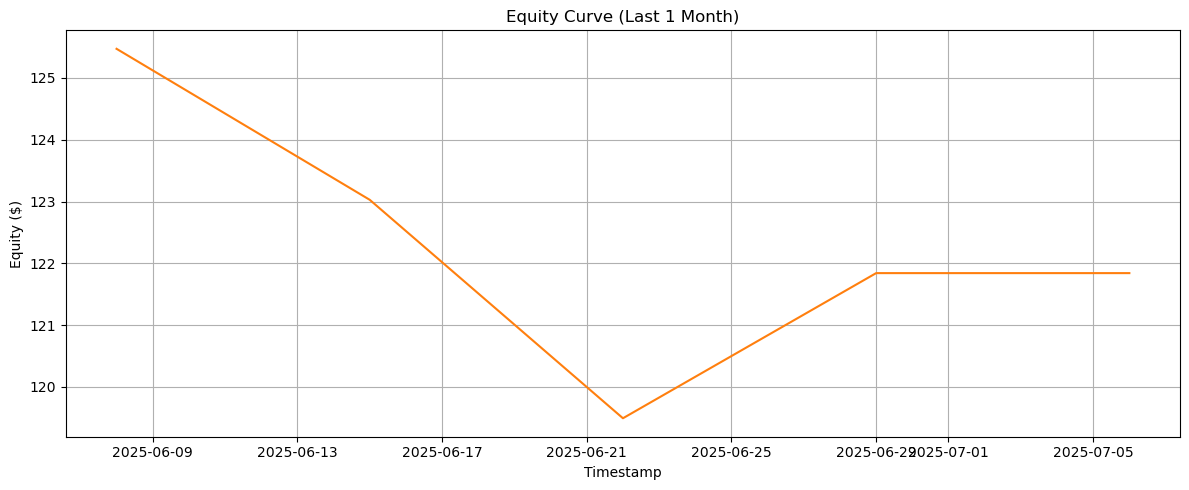

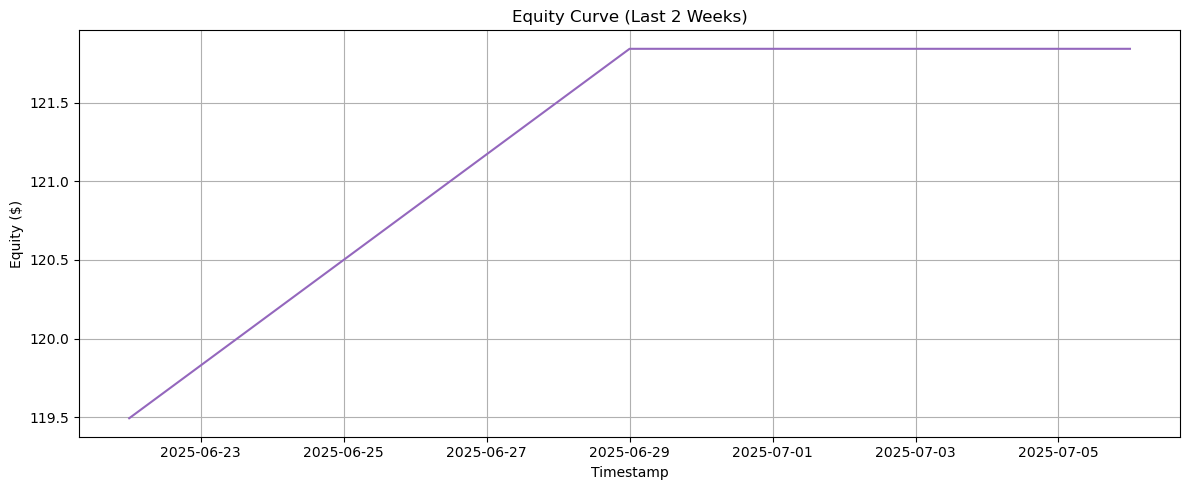

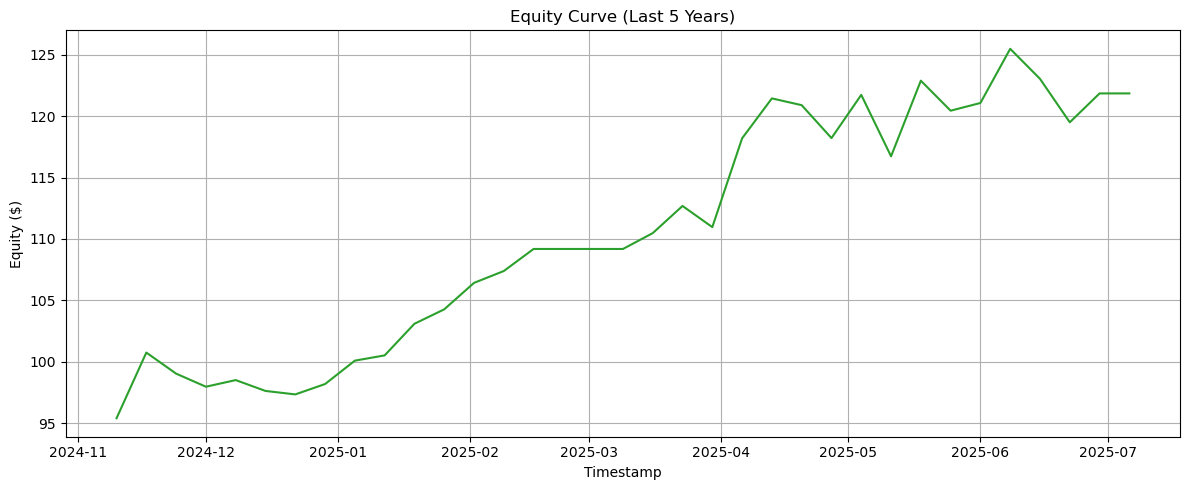

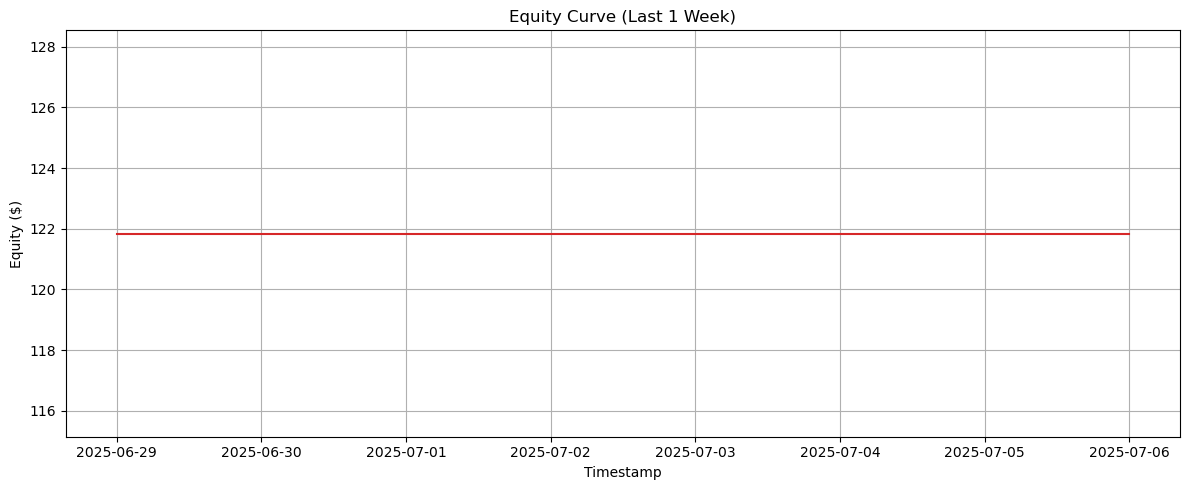

In [45]:
import matplotlib.pyplot as plt
import pandas as pd

#eq_df is the equity DataFrame with a 'timestamp' column
#1 day did not have enough data to produce a graph so did 1 week instead

if 'timestamp' in eq_df.columns:
    eq_df = eq_df.set_index('timestamp')

# --- 1 Month Equity Curve ---
cutoff_1m = eq_df.index.max() - pd.Timedelta(days=30)
eq_1m = eq_df.loc[eq_df.index >= cutoff_1m]
plt.figure(figsize=(12,5))
plt.plot(eq_1m.index, eq_1m['equity'], label='Equity', color='C1')
plt.title("Equity Curve (Last 1 Month)")
plt.xlabel("Timestamp")
plt.ylabel("Equity ($)")
plt.grid(True)
plt.tight_layout()
plt.show()

# --- 2 Weeks Equity Curve ---
cutoff_2w = eq_df.index.max() - pd.Timedelta(days=14)
eq_2w = eq_df.loc[eq_df.index >= cutoff_2w]
plt.figure(figsize=(12,5))
plt.plot(eq_2w.index, eq_2w['equity'], label='Equity', color='C4')
plt.title("Equity Curve (Last 2 Weeks)")
plt.xlabel("Timestamp")
plt.ylabel("Equity ($)")
plt.grid(True)
plt.tight_layout()
plt.show()

# --- 5 Years Equity Curve ---
cutoff_5y = eq_df.index.max() - pd.DateOffset(years=5)
eq_5y = eq_df.loc[eq_df.index >= cutoff_5y]
plt.figure(figsize=(12,5))
plt.plot(eq_5y.index, eq_5y['equity'], label='Equity', color='C2')
plt.title("Equity Curve (Last 5 Years)")
plt.xlabel("Timestamp")
plt.ylabel("Equity ($)")
plt.grid(True)
plt.tight_layout()
plt.show()

# --- 1 Week Equity Curve ---
cutoff_1w = eq_df.index.max() - pd.Timedelta(days=7)
eq_1w = eq_df.loc[eq_df.index >= cutoff_1w]
plt.figure(figsize=(12,5))
plt.plot(eq_1w.index, eq_1w['equity'], label='Equity', color='C3')
plt.title("Equity Curve (Last 1 Week)")
plt.xlabel("Timestamp")
plt.ylabel("Equity ($)")
plt.grid(True)
plt.tight_layout()
plt.show()